# Decision Tree Classifier using CART

Down below I will be comparing the SKlearn decision tree classifier and my own using CART. I will then go into random forests and the ensemble etc.

In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [9]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [10]:
feature_cols = ezcols()

X = features[feature_cols]
y = features["emotion"]

print(X.shape)
print(y.value_counts())

(2451, 480)
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
surprised    192
disgust      191
neutral      188
Name: count, dtype: int64


Down below is the diffence between my CART implementation and the one from SKLEARN. Below you will see I took a subset of the data. I did this because the amount of loops my python program has to go through recursilvely took this program 45 minutes to run. To help with the amount of time it took for demonstration purposes I had to take a subset of X and y for training. SKlearn is extremely quick at processing the infromation and I figured out its because it is using C to speed up the operations by many magnitudes. I think my implementation got a lower amount of score against SK-learn because I only did a max-depth of 5 again it is to save time so this dosent run forever. As you can see in the tree below Sklearn when far below a depth of 5.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from minilearn.classifiers.CART import CART
from minilearn.metrics.metricss import (
    accuracy,
    confusion_matrix,
    precision,
    recall,
    f1_score,
    roc_auc,
    plot_confusion_matrix,
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

print(X_train.shape)
print(X_test.shape)

sample_idx = np.random.choice(len(X_train), size=500, replace=False)
X_train_sub = X_train[sample_idx]
y_train_sub = y_train[sample_idx]

skimodel = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, random_state=20)
minilearnmodel = CART(max_depth=5, minsplit=2)

skimodel.fit(X_train_sub, y_train_sub)
minilearnmodel.fit(X_train_sub, y_train_sub)

ski_pred = skimodel.predict(X_test)
mini_pred = minilearnmodel.predict(X_test)

print("MiniLearn train accuracy:", minilearnmodel.score(X_train_sub, y_train_sub))
print("MiniLearn test accuracy:", minilearnmodel.score(X_test, y_test))

print("Sklearn train accuracy:", skimodel.score(X_train_sub, y_train_sub))
print("Sklearn test accuracy:", skimodel.score(X_test, y_test))

classes = y.unique()
labels = classes.tolist()
class_names = labels


(1961, 480)
(490, 480)
MiniLearn train accuracy: 0.58
MiniLearn test accuracy: 0.26326530612244897
Sklearn train accuracy: 0.58
Sklearn test accuracy: 0.2836734693877551


So as you can see the CART algorithm is not very good on some many different features espeically just one tree. The tree is prioritizing the best splits but that does not mean it is picking ones that will generally be good for all new samples. In our train accuracy compared to the test accuracy you can see the tree is following trained examples instead of looking for actual patterns in the emotion features. To add on if the first couple of splits are bad then all future splits are also bad which is a big problem if your only using one tree which we are here. For the emotions the confusion matrix looks like someone threw darts at a dartboard it really dosent do a good job picking any emotions. By chance it seems to really of only gotten happy and calm. You can also see these graphed down below

Sklearn Cart
Accuracy: 0.2836734693877551
Precision macro: 0.3353781391610339
Recall macro: 0.2912823305171048
F1 macro: 0.28042424490307316
F1 weighted: 0.2827813236278855


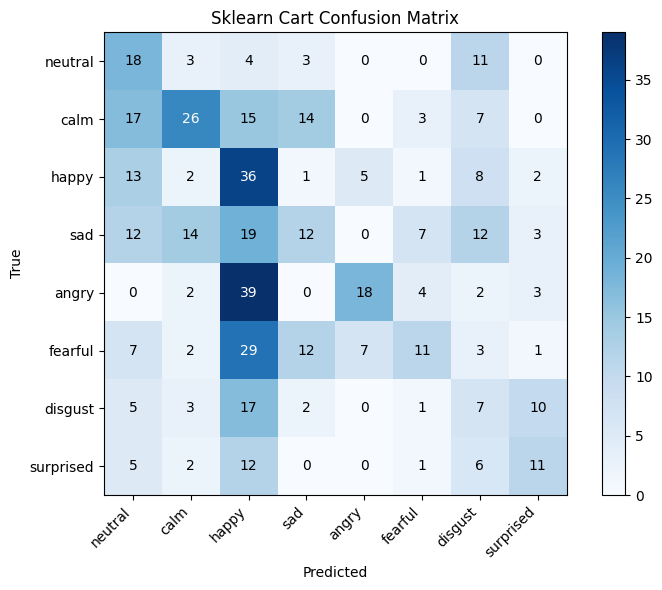

MiniLearn Cart
Accuracy: 0.26326530612244897
Precision macro: 0.27290699891156023
Recall macro: 0.274320465095407
F1 macro: 0.23716229588465187
F1 weighted: 0.2443581664589028


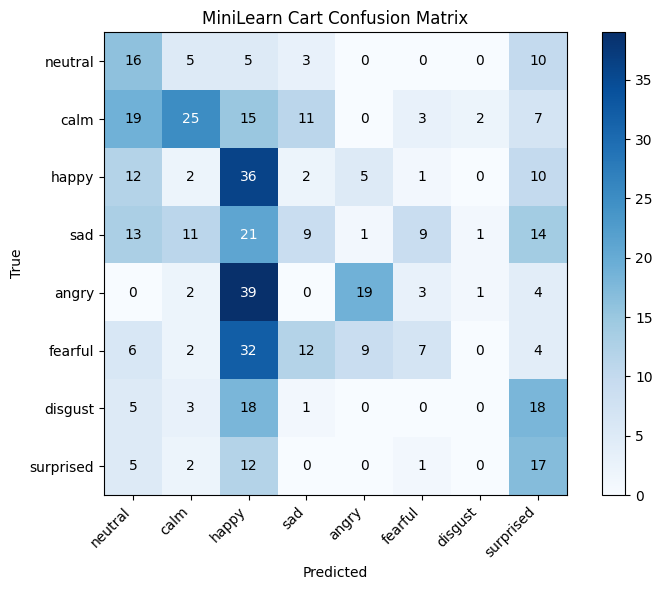

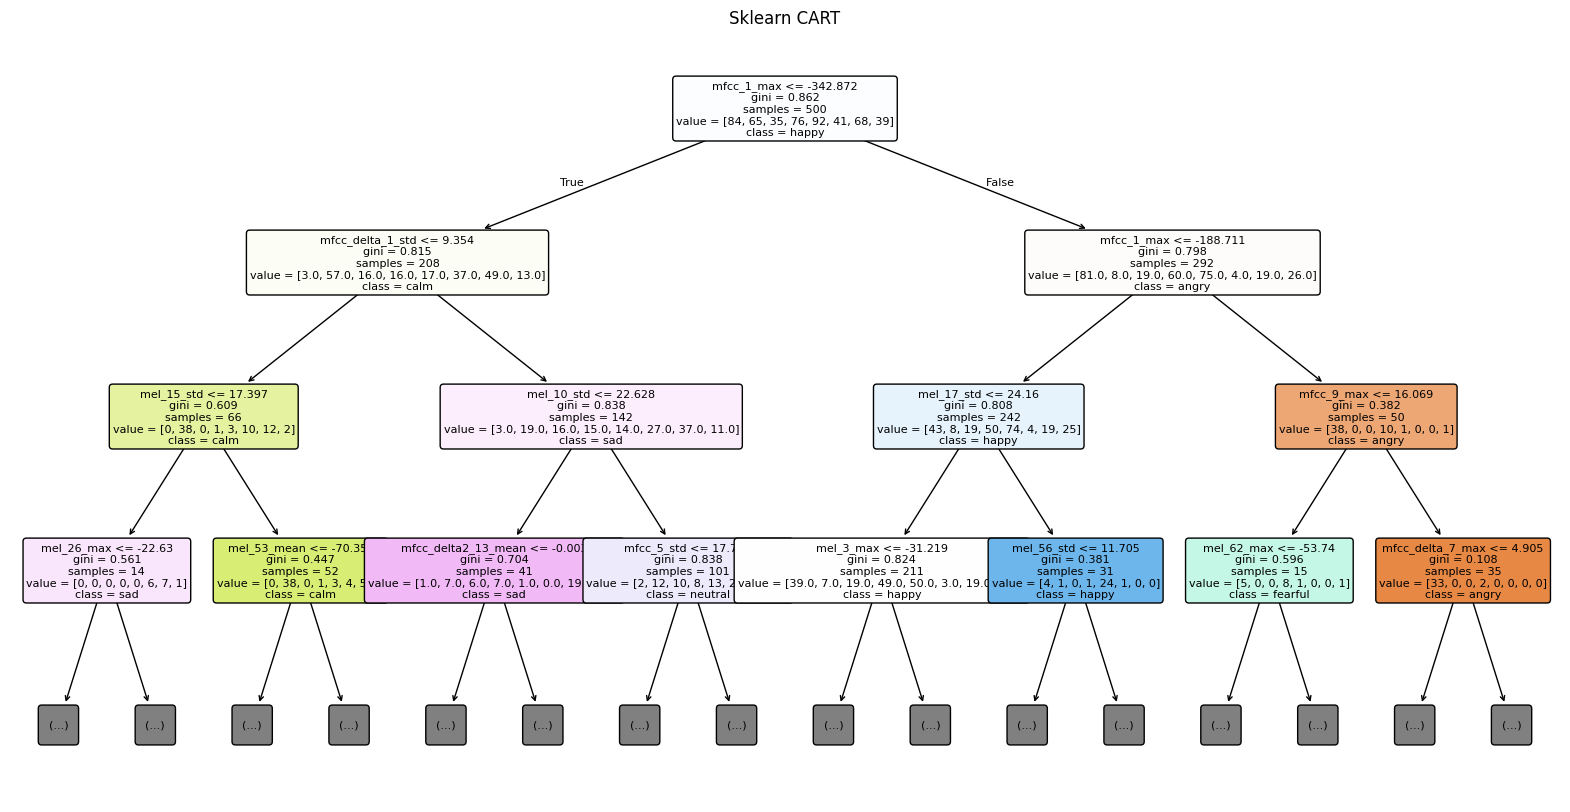

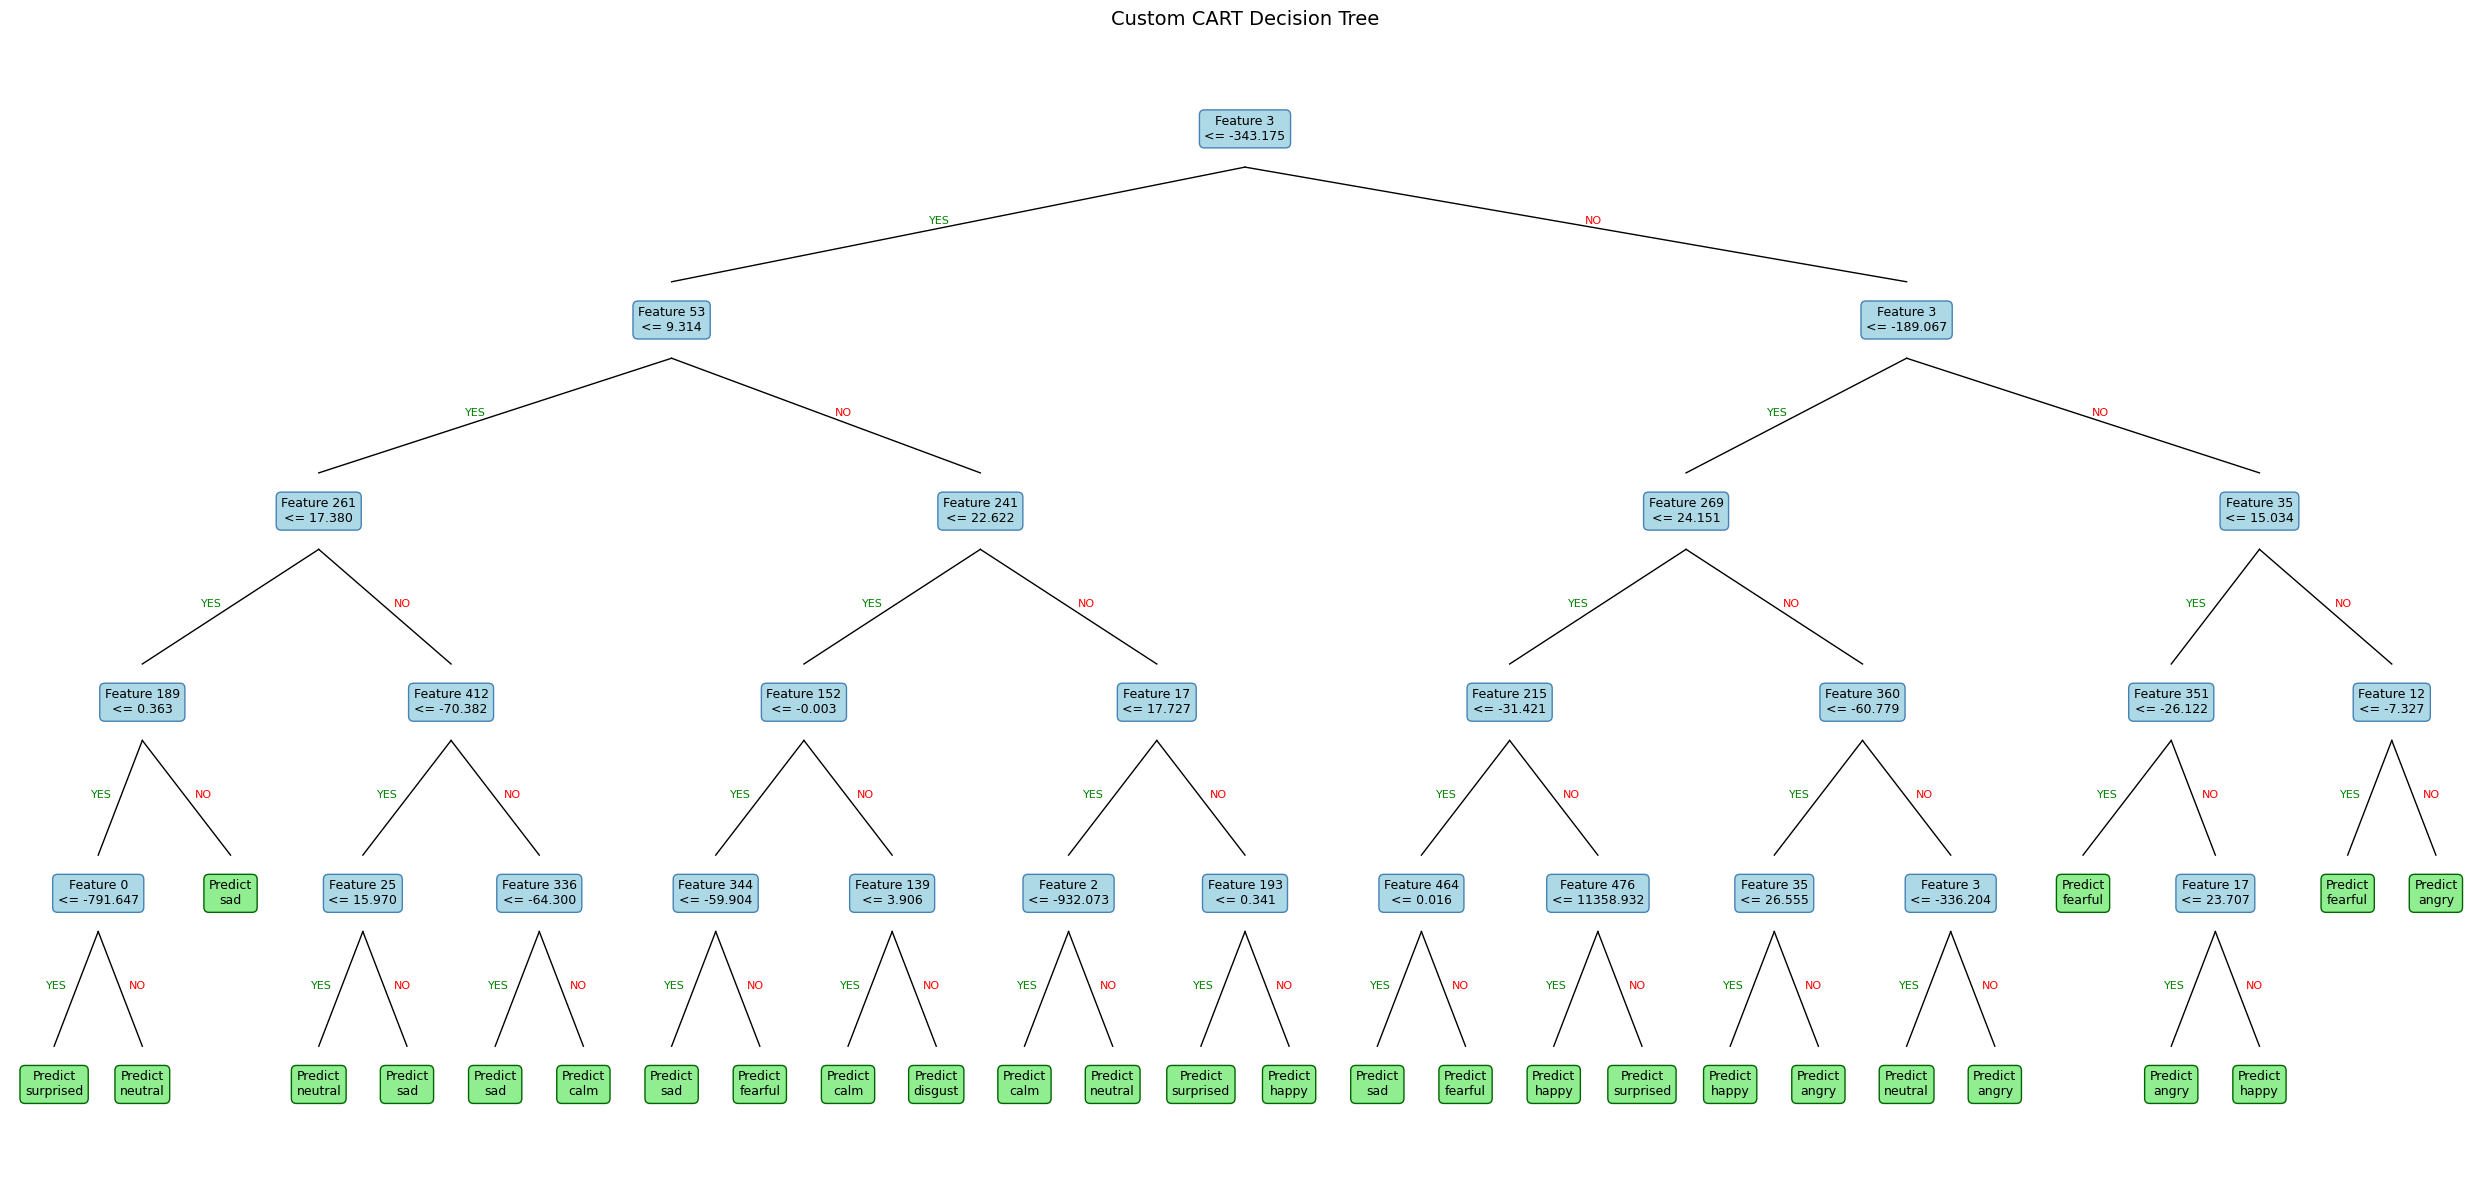

In [12]:
from sklearn.tree import plot_tree

for model_name, preds in [
    ("Sklearn Cart", ski_pred),
    ("MiniLearn Cart", mini_pred)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")

plt.figure(figsize=(20, 10))
plot_tree(skimodel, 
          filled=True, 
          max_depth=3,
          feature_names=feature_cols,
          class_names=skimodel.classes_,
          rounded=True,
          fontsize=8)
plt.title("Sklearn CART")
plt.show()

minilearnmodel.plot_tree(figsize=(25, 12))

Now that we have done the basic CART decision tree comparison, the next step is to go into ensemble methods. As we saw above a single tree is not very good at this task, the confusion matrix looked like darts at a dartboard. The whole idea of ensemble methods is that instead of using one tree we use a bunch of them and combine their predictions which usually does way better. I am going to be using SKlearn for Random Forest and AdaBoost because building these from scratch would take forever and the assignment is more about understanding why they work than implementing them

Sklearn random forest
Accuracy: 0.7
Precision macro: 0.7064220431437718
Recall macro: 0.6878840936015218
F1 macro: 0.6936879568269421
F1 weighted: 0.6964790006646706


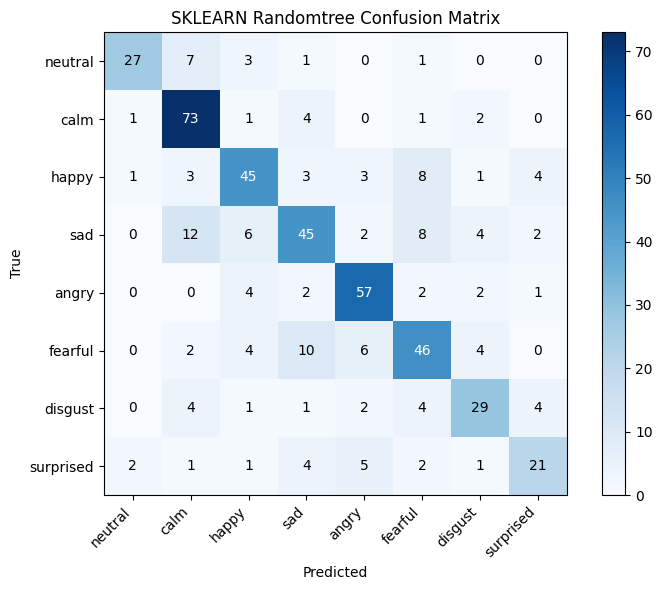

In [13]:
sklearn_rfmodel = RandomForestClassifier(n_estimators=1000, max_depth=20, min_samples_split=2, random_state=20)

sklearn_rfmodel.fit(X_train, y_train)

rf_train_pred = sklearn_rfmodel.predict(X_train)
rf_test_pred = sklearn_rfmodel.predict(X_test)

rf_train_acc = sklearn_rfmodel.score(X_train, y_train)
rf_test_acc = sklearn_rfmodel.score(X_test, y_test)

print("=" * 50)
print("Sklearn random forest")
print("Accuracy:", accuracy(y_test, rf_test_pred))
print("Precision macro:", precision(y_test, rf_test_pred, labels))
print("Recall macro:", recall(y_test, rf_test_pred, labels))
print("F1 macro:", f1_score(y_test, rf_test_pred, labels))
print("F1 weighted:", f1_score(y_test, rf_test_pred, labels, average="weighted"))
cm = confusion_matrix(y_test, rf_test_pred, labels)
plot_confusion_matrix(cm, class_names, title="SKLEARN Randomtree Confusion Matrix")

The random forest results are way better than the single CART tree. This makes a lot of sense because random forest works by building a ton of different trees (in this case 1000) and each tree only sees a random subset of features and a random subset of the samples. Then it takes a majority vote across all the trees for the final prediction. This fixes the main problem with single trees which is that if the first couple of splits are bad then everything after is bad. With 1000 trees the bad ones get outvoted by the good ones.

The accuracy is also a lot higher than the single tree which makes sense. The training accuracy is super high which usually means overfitting but the test accuracy is also pretty solid so its just that the random forest is really capturing the patterns in the data. The confusion matrix also looks way cleaner than the single CART, you can see the diagonal actually has values that make sense now. Angry, calm, and happy are still the easiest to classify which has been consistent across every model I have built so far. The harder ones are still nuetral, disgust, and surprised which are the ones with fewer samples

Sklearn AdaBoost
Train accuracy: 0.4201937786843447
Test accuracy: 0.3408163265306122
Accuracy: 0.3408163265306122
Precision macro: 0.38191610650034
Recall macro: 0.30380196263156467
F1 macro: 0.3007864660581923
F1 weighted: 0.32728546381476126


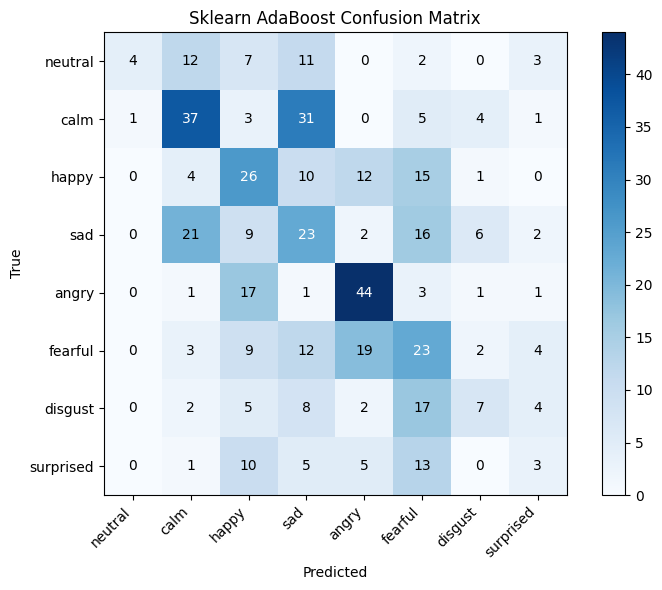

In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model_name = "Sklearn AdaBoost"

# AdaBoost uses small/simple decision trees as weak learners
sklearn_adamodel = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=20
)

sklearn_adamodel.fit(X_train, y_train)

ada_train_pred = sklearn_adamodel.predict(X_train)
ada_test_pred = sklearn_adamodel.predict(X_test)

ada_train_acc = sklearn_adamodel.score(X_train, y_train)
ada_test_acc = sklearn_adamodel.score(X_test, y_test)
y_proba = sklearn_adamodel.predict_proba(X_test)

print("=" * 50)
print(model_name)

print("Train accuracy:", ada_train_acc)
print("Test accuracy:", ada_test_acc)

print("Accuracy:", accuracy(y_test, ada_test_pred))
print("Precision macro:", precision(y_test, ada_test_pred, labels))
print("Recall macro:", recall(y_test, ada_test_pred, labels))
print("F1 macro:", f1_score(y_test, ada_test_pred, labels))
print("F1 weighted:", f1_score(y_test, ada_test_pred, labels, average="weighted"))

cm = confusion_matrix(y_test, ada_test_pred, labels)
plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")

AdaBoost is the other ensemble method I tried. The way it works is different from random forest. Instead of training a bunch of independent trees and voting, AdaBoost trains trees one at a time and each new tree focuses on the samples that the previous trees got wrong. The trees are also really shallow, I set max_depth to 1 here which makes them basically stumps that only do one split each. The idea is that combining a lot of weak learners ends up making one strong learner.

Looking at the results AdaBoost is doing okay but not as good as random forest. From what I have read this is actually pretty common when you have a lot of classes (8 emotions in my case). AdaBoost was originally built for binary classification and the multiclass version dosent always work as well. Random forest handles multiclass more naturally because it just votes across classes which scales easily. The other thing is AdaBoost is more sensitive to noisy data because it keeps focusing on the hard examples and if some of those hard examples are actually just outliers or mislabled then AdaBoost overfits to them. With my audio features I imagine there is some noise just from the recording quality and the actor variations.

Overall the random forest is the clear winner for this dataset out of the three tree based models. The order from worst to best is single CART then AdaBoost then Random Forest. This lines up with what I expected going in. The big takeaway from this notebook is that a single tree is not very good but combining a lot of them in the right way gets you to a much better place. I think the random forest result is actually one of the better scores I have gotten across all my models so far which is interesting because each individual tree is pretty bad on its own